# Mouse EEG-EMG Sleep Staging Pipeline

Runs three open-source sleep-staging methods end-to-end, starting from the raw
Intan DAT files, then aggregates statistics and figures:

| # | Method | Principle | Input | Output |
|---|--------|-----------|-------|--------|
| 1 | **REST** | Pre-trained Transformer (no training needed) | EDF (EEG channel name contains `RF` + EMG) | `.mat`, one score per 4 s epoch |
| 2 | **somnotate** | LDA + HMM (trained on 12 h manually annotated pilot data) | EDF (2×EEG + EMG) | `.hyp` state intervals |
| 3 | **AccuSleePy** | SSANN (OSF pre-trained 4 s model) | parquet (eeg/emg @1 kHz) | labels csv |

**Data flow:** DAT (int16 @30 kHz) → 0.195 µV/bit conversion → chunked
anti-aliasing decimation to 1 kHz → 50/100 Hz notch → EDF/parquet → three
stagings → alignment (Wake/NREM/REM) → statistics and figures.

**Environment notes**
- This notebook runs in the `eegemg` environment (Python 3.11). somnotate
  depends on `pomegranate<1.0` (Python ≤ 3.9), so it runs as a subprocess in
  the separate `somnotate39` environment (path configured below).
- The `eegemg` environment now ships CUDA torch (`2.14.0+cu130`), so REST
  runs on the GPU automatically (the REST cell prints which device it uses).
  To reinstall: `pip install torch==2.14.0+cu130 torchvision==0.29.0+cu130
  --index-url https://download.pytorch.org/whl/cu130`.

**How to use**
- **Every run = one new folder.** Each full execution of the notebook creates
  `results/<recording><TAG>_<timestamp>/` holding that run's three staging
  results, the statistics table and all figures. Historical runs are never
  overwritten.
- **New recording:** edit only the *Recording info* block below (data folder,
  name, start time, channel map), then run all cells top to bottom. Expensive
  intermediates (1 kHz decimation cache, somnotate preprocessing and trained
  model) are reused automatically.
- **Force re-decimation from DAT:** set `RERUN = ["dat"]`. The cache is keyed
  on source file + size, so new data is detected automatically; this flag is
  only for special cases.
- **Analyze a sub-interval:** set `TIME_CLIP = (start_sec, end_sec)` (relative
  to recording start; `None` end = until the end), e.g. first 30 min
  `(0, 1800)`. All staging, statistics and figures then cover only that span.
- **Channel map verified:** A-001/002 = EMG, A-003/004 = EEG (based on
  same-channel delta–HF correlation and the NREM/Wake delta power ratio).

In [1]:
from datetime import datetime

# ===== Recording info (edit this block for a new recording) =============
REC_DIR  = r"D:\code\eeg-emg\sample\20260930-test\test_260930_144535"  # Intan one-file-per-channel folder
REC_NAME = "test"                                # recording label (output prefix)
START    = datetime(2026, 9, 30, 14, 45, 35)     # recording start (wall clock);
                                                 # set to None if unknown -> figures show elapsed time

# Channel map: Intan file -> (channel label, kind)
CHANNELS = {
    "amp-A-001.dat": ("EMG1", "emg"),
    "amp-A-002.dat": ("EMG2", "emg"),
    "amp-A-003.dat": ("EEG1", "eeg"),
    "amp-A-004.dat": ("EEG2", "eeg"),
}
EEG_CH, EMG_CH = "EEG1", "EMG1"        # primary channels used for staging & plots

# ===== Sampling and parameters ==========================================
FS_RAW, FS = 30000, 1000               # raw / working sampling rate (Hz)
UV_PER_BIT = 0.195                     # Intan int16 -> µV
EPOCH = 4.0                            # staging epoch length (s)

# ===== Optional: analyze only a time span (s, from recording start) =====
TIME_CLIP = None                       # e.g. first 30 min -> (0, 1800)

# ===== Force re-decimation from DAT (normally keep empty) ===============
RERUN = []   # optional "dat": drop cache and re-decimate from DAT

# ===== Paths ============================================================
from pathlib import Path
ROOT      = Path(r"D:\code\eeg-emg")
EDF_DIR   = ROOT / "edf"
CACHE_DIR = EDF_DIR / "cache"
REST_DIR  = EDF_DIR / "rest"           # REST EDF input (intermediate)
SOM_DIR   = ROOT / "somnotate_run"     # somnotate working dir (scripts & intermediates)
ACC_DIR   = ROOT / "accusleepy_run"    # AccuSleePy model & intermediates
RESULTS   = ROOT / "results"           # one new sub-folder is created here per run

# somnotate runtime environment (Python 3.9 + pomegranate<1.0)
SOMNOTATE_PY = Path(r"C:\Users\24690\anaconda3\envs\somnotate39\python.exe")

TAG    = "" if TIME_CLIP is None else f"_clip{TIME_CLIP[0]}-{TIME_CLIP[1]}"
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = RESULTS / f"{REC_NAME}{TAG}_{RUN_TS}"   # output folder of this run
for d in (CACHE_DIR, REST_DIR, SOM_DIR / "data" / "raw", SOM_DIR / "data" / "processed",
          ACC_DIR, RUN_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Recording: {REC_NAME}  folder: {REC_DIR}")
print(f"Output folder of this run: {RUN_DIR}")
print(f"TIME_CLIP = {TIME_CLIP}  RERUN = {RERUN}")

Recording: test  folder: D:\code\eeg-emg\sample\20260930-test\test_260930_144535
Output folder of this run: D:\code\eeg-emg\results\test_20260930_204314
TIME_CLIP = None  RERUN = []


In [2]:
import os, sys, json, time, shutil, subprocess
import numpy as np
import pandas as pd
from scipy import signal
from scipy.io import loadmat, savemat
import matplotlib.pyplot as plt

STATE_NAMES  = {0: "Unknown", 1: "Wake", 2: "NREM", 3: "REM"}
STATE_COLORS = {1: "#DC267F", 2: "#648FFF", 3: "#FFB000"}
TOOLS = ["REST", "somnotate", "AccuSleePy"]


def notch50(x, fs=FS):
    """Zero-phase notch at 50/100 Hz (line noise and its harmonic)."""
    x = np.asarray(x, dtype=np.float64)
    for f0 in (50.0, 100.0):
        b, a = signal.iirnotch(f0, Q=30, fs=fs)
        x = signal.filtfilt(b, a, x)
    return x.astype(np.float32)


# ---- Readers for the three staging outputs (unified coding 0=Unknown,
#      1=Wake, 2=NREM, 3=REM) ----
def load_rest_scores(path):
    """REST .mat score: 1=Wake 2=NREM 3=REM 4=artifact."""
    s = loadmat(path)["score"].flatten().astype(int)
    return np.array([{1: 1, 2: 2, 3: 3}.get(x, 0) for x in s], dtype=int)


def load_somnotate_vec(path):
    """somnotate .hyp (state name + cumulative end time) -> one code per 4 s."""
    ends, labels = [], []
    for line in open(path):
        line = line.strip()
        if not line or line.startswith("*"):
            continue
        parts = line.split()
        try:
            ends.append(float(parts[-1]))
        except ValueError:
            continue
        labels.append(parts[0])
    n = int(ends[-1] / EPOCH)
    out = np.zeros(n, dtype=int)
    m = {"awake": 1, "non-REM": 2, "REM": 3}
    prev = 0.0
    for lab, end in zip(labels, ends):
        out[int(prev / EPOCH):min(int(end / EPOCH), n)] = m.get(lab, 0)
        prev = end
    return out


def load_accusleepy_vec(path):
    """AccuSleePy labels csv: 1=REM 2=Wake 3=NREM."""
    df = pd.read_csv(path)
    return np.array([{1: 3, 2: 1, 3: 2}.get(x, 0) for x in df["brain_state"]], dtype=int)


print("Utility functions ready")

Utility functions ready


## 1. Read raw DAT data

Intan RHX "One File Per Channel" format: `amp-A-00X.dat` holds int16 samples
(0.195 µV/bit) and `time.dat` holds int32 sample indices. This section first
verifies timeline continuity and the recording duration, then decimates each
channel to 1 kHz (chunked anti-aliasing with `resample_poly`). Results are
cached as `.npy`; repeated runs load the cache directly.

In [3]:
from datetime import timedelta

# ---- Timeline check --------------------------------------------------------
t = np.fromfile(os.path.join(REC_DIR, "time.dat"), dtype=np.int32)
n_raw = len(t)
step = max(1, n_raw // 1000)
contig = (np.array_equal(t[:1000], np.arange(min(1000, n_raw)))
          and np.array_equal(t[::step], np.arange(0, n_raw, step)))
dur_raw = n_raw / FS_RAW
print(f"Raw samples {n_raw:,} @ {FS_RAW} Hz -> duration {dur_raw:.0f} s = {dur_raw / 3600:.2f} h")
print(f"Timeline contiguous: {'yes' if contig else 'NO (gaps found!)'}")
if START is not None:
    print(f"Recording span: {START:%Y-%m-%d %H:%M:%S} -> {START + timedelta(seconds=dur_raw):%H:%M:%S}")
if not contig and TIME_CLIP is None:
    print("!! Timeline is not contiguous; consider TIME_CLIP to keep valid data only")


def resample_stream(path, fs_in=FS_RAW, fs_out=FS, down=30, block_sec=10.0, ov_sec=1.0):
    """int16 dat -> float32 µV, chunked (10 s block + 1 s overlap) anti-aliasing decimation."""
    n_samples = os.path.getsize(path) // 2
    block, ov = int(block_sec * fs_in), int(ov_sec * fs_in)
    n_out = int(np.ceil(n_samples * fs_out / fs_in))
    out = np.empty(n_out, dtype=np.float32)
    pos_in, first, i1 = 0, True, 0
    while pos_in < n_samples:
        start, end = max(0, pos_in - ov), min(n_samples, pos_in + block)
        x = np.fromfile(path, dtype=np.int16, count=end - start, offset=start * 2).astype(np.float64) * UV_PER_BIT
        y = signal.resample_poly(x, 1, down)
        head = 0 if first else int(ov * fs_out / fs_in)
        i0 = int(np.floor(start * fs_out / fs_in)) + head
        y_new = y[head:]
        i1 = min(n_out, i0 + len(y_new))
        out[i0:i1] = y_new[:i1 - i0]
        pos_in, first = end, False
    return out[:i1]


sigs_uv = {}
for fname, (label, kind) in CHANNELS.items():
    stem = Path(fname).stem
    cache = CACHE_DIR / f"{REC_NAME}_{stem}_{FS}.npy"
    meta_f = CACHE_DIR / f"{REC_NAME}_{stem}_{FS}.json"
    meta = {"src": str(Path(REC_DIR) / fname), "size": os.path.getsize(os.path.join(REC_DIR, fname))}
    if (cache.exists() and meta_f.exists() and json.loads(meta_f.read_text()) == meta
            and "dat" not in RERUN):
        sigs_uv[label] = np.load(cache)
        print(f"[skip] {label}: cache hit ({len(sigs_uv[label]):,} samples)")
        continue
    print(f"Decimating {fname} -> {label} ...", flush=True)
    y = resample_stream(os.path.join(REC_DIR, fname))
    np.save(cache, y)
    meta_f.write_text(json.dumps(meta))
    sigs_uv[label] = y
    print(f"  {len(y):,} samples ({len(y) / FS:.1f} s), std = {y.std():.1f} µV")

n = min(map(len, sigs_uv.values()))
sigs_uv = {k: v[:n] for k, v in sigs_uv.items()}
print(f"All channels aligned to {n:,} samples = {n / FS:.1f} s")

Raw samples 290,658,048 @ 30000 Hz -> duration 9689 s = 2.69 h
Timeline contiguous: yes
Recording span: 2026-09-30 14:45:35 -> 17:27:03
Decimating amp-A-001.dat -> EMG1 ...


  9,688,602 samples (9688.6 s), std = 82.0 µV
Decimating amp-A-002.dat -> EMG2 ...


  9,688,602 samples (9688.6 s), std = 84.9 µV
Decimating amp-A-003.dat -> EEG1 ...


  9,688,602 samples (9688.6 s), std = 68.3 µV
Decimating amp-A-004.dat -> EEG2 ...


  9,688,602 samples (9688.6 s), std = 63.2 µV
All channels aligned to 9,688,602 samples = 9688.6 s


Signals used for analysis: 9688.6 s = 2.69 h, starting at 14:45:35


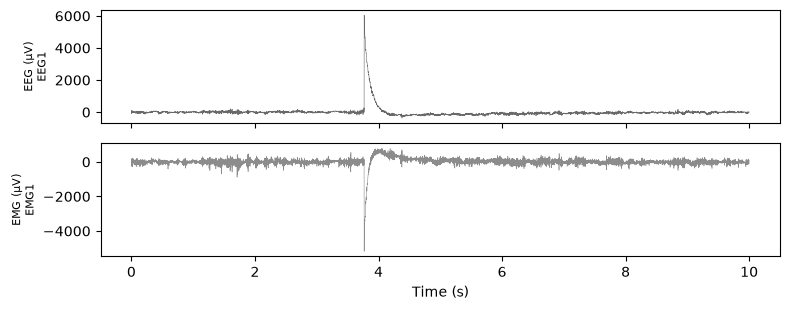

In [4]:
# ---- 50/100 Hz notch + optional time clip ----------------------------------
sigs = {k: notch50(v) for k, v in sigs_uv.items()}
start_dt = START                    # wall-clock start of the analyzed span (None = unknown)
if TIME_CLIP is not None:
    tc0, tc1 = TIME_CLIP
    a = int((tc0 or 0) * FS)
    b = n if tc1 is None else min(int(tc1 * FS), n)
    sigs = {k: v[a:b] for k, v in sigs.items()}
    if START is not None:
        start_dt = START + timedelta(seconds=a / FS)
n = len(next(iter(sigs.values())))
dur_s = n / FS
t0_txt = f", starting at {start_dt:%H:%M:%S}" if start_dt is not None else ""
print(f"Signals used for analysis: {dur_s:.1f} s = {dur_s / 3600:.2f} h{t0_txt}")

# ---- QA: 10 s raw traces taken at the 10 min mark --------------------------
i0 = int(min(600, max(0, dur_s - 10)) * FS)
seg = np.arange(10 * FS) / FS
fig, axes = plt.subplots(2, 1, figsize=(8, 3.2), sharex=True)
axes[0].plot(seg, sigs[EEG_CH][i0:i0 + 10 * FS], lw=0.4, color="#696969")
axes[0].set_ylabel(f"EEG (µV)\n{EEG_CH}", fontsize=8)
axes[1].plot(seg, sigs[EMG_CH][i0:i0 + 10 * FS], lw=0.4, color="#8C8C8C")
axes[1].set_ylabel(f"EMG (µV)\n{EMG_CH}", fontsize=8)
axes[1].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()

## 2. Export EDF (input for REST and somnotate)

Writes a 1 kHz EDF (channels `RF_EEG / EEG2 / EMG / EMG2`; REST requires the
EEG channel name to contain `RF` and the EMG channel name to contain `EMG`)
and copies it into the somnotate data folder. Also generates the somnotate
train/apply spreadsheets (train.csv uses the 12 h manually annotated Zenodo
pilot; the model is trained only once).

In [5]:
import pyedflib
from datetime import datetime

edf_rest = REST_DIR / f"{REC_NAME}{TAG}.edf"
som_edf  = SOM_DIR / "data" / "raw" / f"{REC_NAME}{TAG}.edf"


def write_edf(path, sig_list, fs, start, ch_names):
    f = pyedflib.EdfWriter(str(path), len(sig_list), file_type=pyedflib.FILETYPE_EDFPLUS)
    headers = [dict(label=nm, dimension="mV", sample_frequency=fs,
                    physical_min=-6.388, physical_max=6.388,      # ±32768 × 0.195 µV
                    digital_min=-32768, digital_max=32767,
                    transducer="Intan RHS", prefilter="DSP 1Hz HP + notch 50/100 Hz")
               for nm in ch_names]
    f.setStartdatetime(start if start is not None else datetime(1970, 1, 1))  # placeholder date
    f.setSignalHeaders(headers)
    f.writeSamples(np.vstack(sig_list) / 1000.0)   # µV -> mV
    f.close()


order = ["EEG1", "EEG2", "EMG1", "EMG2"]       # REST requires 'RF' in the EEG channel name
names = ["RF_EEG", "EEG2", "EMG", "EMG2"]
write_edf(edf_rest, [sigs[k] for k in order], FS, start_dt, names)
shutil.copy2(edf_rest, som_edf)
print(f"Written {edf_rest}")
print(f"Copied  {som_edf}")

Written D:\code\eeg-emg\edf\rest\test.edf
Copied  D:\code\eeg-emg\somnotate_run\data\raw\test.edf


## 3. Method 1: REST (pre-trained Transformer)

Direct inference with the pre-trained model from SukiyakiP/REST
(`Deeper_and_wider/best_acc.pth`): signals are resampled to 512 Hz, split into
4 s epochs and scored as 1=Wake 2=NREM 3=REM 4=artifact, followed by
Viterbi/HMM smoothing, short-bout merging and rule-based artifact filtering.
The checkpoint already lives in `tools/REST/checkpoints/`.

In [6]:
rest_mat = RUN_DIR / f"{REC_NAME}{TAG}_REST_V2.0.mat"


def filter_short_bouts(score, min_epochs):
    """Merge bouts shorter than min_epochs[stage] into the preceding bout."""
    out = score.copy()
    i = 0
    while i < len(out):
        j = i
        while j < len(out) and out[j] == out[i]:
            j += 1
        if (j - i) < min_epochs.get(int(out[i]), 1):
            out[i:j] = out[i - 1] if i > 0 else (out[j] if j < len(out) else out[i])
        i = j
    return out


def _run_rest():
    import torch, mne, gc
    import torch.nn.functional as F
    from torch.utils.data import DataLoader
    sys.path.insert(0, str(ROOT / "tools" / "REST"))
    from RESTCORE import REST
    from RESTutils import (data_process_tensor, create_sequences,
                           compute_powers_welch_tensor, viterbi_smooth)
    from ArtifactFilter import flag_artifacts
    mne.set_log_level("ERROR")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("REST device:", device)
    ckpt = ROOT / "tools" / "REST" / "checkpoints" / "Deeper_and_wider"
    model = REST(in_feat=130, n_classes=4, win_len=120, d_model=384, nhead=8,
                 nlayers_epoch=4, nlayers_seq=6, ff=768, fc_hidden1=256,
                 fc_hidden2=128, dropout=0.15, use_layernorm=True).to(device)
    model.load_state_dict(torch.load(ckpt / "best_acc.pth", weights_only=True,
                                     map_location=device))
    model.eval()

    raw = mne.io.read_raw_edf(str(edf_rest), preload=True, verbose=False)
    if raw.info["sfreq"] != 512:
        raw.resample(512)
    ch = raw.info["ch_names"]
    eeg_ix = [i for i, nm in enumerate(ch) if "RF" in nm and "LP" not in nm]
    emg_ix = [i for i, nm in enumerate(ch) if "EMG" in nm]
    if not eeg_ix or not emg_ix:
        raise RuntimeError(f"EDF is missing RF/EMG channels: {ch}")
    EEG, EMG = raw.get_data(eeg_ix), raw.get_data(emg_ix[0])
    raw.close()

    with torch.no_grad():
        power = compute_powers_welch_tensor(EEG * 1e6, EMG * 1e6, sfreq=512, s=4, device=device)
        EEG_STFT, EMG_STFT = data_process_tensor(EEG, EMG, fs=512, device=device)
        STFT = np.concatenate((EEG_STFT, EMG_STFT), axis=-1)
        n_epochs = len(STFT)
        X = create_sequences(data=STFT, window_size=120, step=90)
        loader = DataLoader(torch.tensor(X, dtype=torch.float32), batch_size=256, shuffle=False)
        preds = []
        for batch in loader:
            probs = F.softmax(model(batch.to(device)), dim=2)[:, :90, :]
            preds.append(probs.cpu().numpy())
        probs_flat = np.concatenate(preds, axis=0).reshape(-1, 4)
        if len(probs_flat) < n_epochs:          # tail epochs not covered by a full window
            tail = n_epochs - len(probs_flat)
            tw = STFT[max(0, n_epochs - 120):n_epochs]
            if len(tw) < 120:
                tw = np.concatenate([np.zeros((120 - len(tw), STFT.shape[1]), np.float32), tw])
            t_in = torch.tensor(tw[np.newaxis], dtype=torch.float32).to(device)
            probs_flat = np.concatenate(
                [probs_flat, F.softmax(model(t_in), dim=2)[0, -tail:, :].cpu().numpy()])
        score = viterbi_smooth(probs_flat) + 1

    score = filter_short_bouts(score, {1: 1, 2: 3, 3: 3, 4: 2})
    art = flag_artifacts(EEG[0], fs=512, epoch_seconds=4)
    m = min(len(art), len(score))
    score[:m][art[:m]] = 4
    savemat(rest_mat, {"score": score, "power": power})
    del EEG, EMG, STFT, X
    gc.collect()
    print(f"Saved {rest_mat} ({len(score)} epochs)")


_run_rest()
rest_vec = load_rest_scores(rest_mat)
print(f"REST: {len(rest_vec)} epochs;",
      ", ".join(f"{STATE_NAMES[s]} {(rest_vec == s).sum()} ({100 * (rest_vec == s).sum() / len(rest_vec):.1f}%)"
                for s in (1, 2, 3)))

REST device: cuda


Saved D:\code\eeg-emg\results\test_20260930_204314\test_REST_V2.0.mat (2422 epochs)
REST: 2422 epochs; Wake 943 (38.9%), NREM 1426 (58.9%), REM 53 (2.2%)


## 4. Method 2: somnotate (LDA + HMM)

Trains an LDA+HMM model on the pilot 12 h manually annotated dataset (Zenodo
doi:10.5281/zenodo.10200482) once, then applies it to this recording. Because
it needs `pomegranate<1.0` (Python ≤ 3.9), this step runs as a **subprocess in
the somnotate39 environment**, calling:

1. `01_preprocess_signals.py` — 1–90 Hz spectrum + log + robust standardization
2. `03_train_state_annotation.py` — training (skipped if the model exists)
3. `04_run_state_annotation.py` — prediction, writes `.hyp` (state + cumulative end time)

In [7]:
som_hyp = RUN_DIR / f"{REC_NAME}{TAG}_automated.hyp"
SOM_MODEL = SOM_DIR / "data" / "processed" / "trained_model.pickle"


def _write_som_csv():
    """Write the somnotate train/apply spreadsheets (relative paths based on SOM_DIR)."""
    train = {"file_path_raw_signals": "./data/raw/pilot.edf",
             "frontal_eeg_signal_label": "Signal 0", "occipital_eeg_signal_label": "Signal 1",
             "emg_signal_label": "Signal 3", "sampling_frequency_in_hz": 256,
             "file_path_preprocessed_signals": "./data/processed/pilot.npy",
             "file_path_manual_state_annotation": "./data/raw/pilot_consensus.hyp",
             "file_path_automated_state_annotation": "./data/processed/pilot_automated.hyp",
             "file_path_refined_state_annotation": "./data/processed/pilot_refined.hyp",
             "file_path_review_intervals": "./data/processed/pilot_review.csv",
             "file_path_state_probabilities": "./data/processed/pilot_probs.npz"}
    stem = f"{REC_NAME}{TAG}"
    apply_ = {"file_path_raw_signals": f"./data/raw/{stem}.edf",
              "frontal_eeg_signal_label": "RF_EEG", "occipital_eeg_signal_label": "EEG2",
              "emg_signal_label": "EMG", "sampling_frequency_in_hz": FS,
              "file_path_preprocessed_signals": f"./data/processed/{stem}.npy",
              "file_path_manual_state_annotation": f"./data/processed/{stem}_refined.hyp",
              "file_path_automated_state_annotation": str(RUN_DIR / f"{stem}_automated.hyp"),
              "file_path_refined_state_annotation": f"./data/processed/{stem}_refined.hyp",
              "file_path_review_intervals": f"./data/processed/{stem}_review.csv",
              "file_path_state_probabilities": f"./data/processed/{stem}_probs.npz"}
    pd.DataFrame([train]).to_csv(SOM_DIR / "train.csv", index=False)
    pd.DataFrame([apply_]).to_csv(SOM_DIR / "apply.csv", index=False)


def _sh(*args):
    print("$", *args, flush=True)
    env = {**os.environ, "MPLBACKEND": "Agg"}     # do not inherit the notebook inline backend
    for attempt in range(3):                      # retry around transient file locks (AV scans)
        r = subprocess.run([str(SOMNOTATE_PY), *args], cwd=str(SOM_DIR), env=env,
                           capture_output=True, text=True, errors="replace")
        if r.returncode == 0:
            print((r.stdout or "")[-1500:])
            return
        print(f"  attempt {attempt + 1} failed (rc={r.returncode}), retrying in 8 s...")
        print((r.stdout or "")[-800:]); print((r.stderr or "")[-800:])
        time.sleep(8)
    raise RuntimeError(f"somnotate step failed: {' '.join(args)}\n"
                       f"stderr tail: {(r.stderr or '')[-1000:]}")


def _run_somnotate():
    _write_som_csv()
    if not (SOM_DIR / "data" / "processed" / "pilot.npy").exists():
        _sh("01_preprocess_signals.py", "train.csv")     # pilot preprocessing (first run only)
    _sh("01_preprocess_signals.py", "apply.csv")         # this recording
    if not SOM_MODEL.exists():
        _sh("03_train_state_annotation.py", "train.csv",
            "./data/processed/trained_model.pickle")     # training (first run only)
    _sh("04_run_state_annotation.py", "apply.csv",
        "./data/processed/trained_model.pickle")         # prediction


_run_somnotate()
som_vec = load_somnotate_vec(som_hyp)
print(f"somnotate: {len(som_vec)} epochs;",
      ", ".join(f"{STATE_NAMES[s]} {(som_vec == s).sum()} ({100 * (som_vec == s).sum() / len(som_vec):.1f}%)"
                for s in (1, 2, 3)))

$ 01_preprocess_signals.py apply.csv


./data/raw/test.edf (1/1)

$ 04_run_state_annotation.py apply.csv ./data/processed/trained_model.pickle


./data/processed/test.npy (1/1)
    Annotating states...

somnotate: 2422 epochs; Wake 948 (39.1%), NREM 1383 (57.1%), REM 91 (3.8%)


## 5. Method 3: AccuSleePy (SSANN)

Uses the OSF pre-trained 4 s SSANN model (`ssann_4s.pth`; if missing, download
it from https://osf.io/py5eb/ under `python_format/models/` into
`accusleepy_run/`). AccuSleePy requires a calibration file per recording; here
it is built from **REST ∩ somnotate agreeing epochs as pseudo-labels** (used
only for feature normalization, not model training). Its label coding is
1=REM 2=Wake 3=NREM and is remapped on load.

In [8]:
acc_csv = RUN_DIR / f"{REC_NAME}{TAG}_accusleepy_labels.csv"
rec_path = ACC_DIR / f"{REC_NAME}{TAG}.parquet"


def _run_accusleepy():
    from accusleepy.fileio import Recording, EMGFilter
    from accusleepy.brain_state_set import BrainState, BrainStateSet
    from accusleepy.services import create_calibration, score_recording_list, LoadedModel
    from accusleepy.models import load_model
    from accusleepy import constants as c

    # ---- recording: trim to whole epochs -> parquet (columns eeg/emg) ----
    n_ep = int(dur_s / EPOCH)
    nn = n_ep * int(FS * EPOCH)
    pd.DataFrame({"eeg": sigs[EEG_CH][:nn], "emg": sigs[EMG_CH][:nn]}).to_parquet(rec_path)
    print(f"Recording {nn} samples = {nn / FS:.1f} s, {n_ep} epochs")

    # ---- pseudo-labels: REST ∩ somnotate agreement (recoded to AccuSleePy digits) ----
    rest_raw = loadmat(rest_mat)["score"].flatten().astype(int)      # 1W 2N 3R 4artifact
    rest_d = np.array([{1: 2, 2: 3, 3: 1, 4: -1}.get(x, -1) for x in rest_raw])
    som_d = np.array([{1: 2, 2: 3, 3: 1}.get(x, -1) for x in load_somnotate_vec(som_hyp)])
    L = min(len(rest_d), len(som_d))
    agree = (som_d[:L] > 0) & (rest_raw[:L] <= 3) & (rest_d[:L] == som_d[:L])
    pseudo = np.full(n_ep, -1, dtype=int)
    pseudo[:L] = np.where(agree, som_d[:L], -1)
    pseudo_path = ACC_DIR / f"{REC_NAME}{TAG}_pseudo_labels.csv"
    pd.DataFrame({"brain_state": pseudo}).to_csv(pseudo_path, index=False)
    print("Pseudo-labels (for calibration):", int((pseudo > 0).sum()), "/", n_ep, "epochs")

    # ---- model + calibration + scoring ----
    model, model_epoch, epochs_per_img, model_type, bsd = load_model(str(ACC_DIR / "ssann_4s.pth"))
    assert model_epoch == EPOCH, f"model epoch length {model_epoch} differs from setting"
    bss = BrainStateSet([BrainState(name=d["name"], digit=d["digit"],
                                    is_scored=d["is_scored"], frequency=d["frequency"])
                         for d in bsd], c.UNDEFINED_LABEL)
    emg_filter = EMGFilter(order=c.DEFAULT_EMG_FILTER_ORDER,
                           bp_lower=c.DEFAULT_EMG_BP_LOWER, bp_upper=c.DEFAULT_EMG_BP_UPPER)
    recording = Recording(name=1, recording_file=str(rec_path), label_file=str(pseudo_path),
                          calibration_file="", sampling_rate=FS)
    cal_path = ACC_DIR / f"{REC_NAME}{TAG}_calibration.csv"
    r = create_calibration(recording, EPOCH, bss, emg_filter, str(cal_path))
    if not r.success:
        raise RuntimeError(f"calibration failed: {r.error}")
    recording.calibration_file = str(cal_path)
    recording.label_file = str(acc_csv)
    loaded = LoadedModel(model=model, epoch_length=model_epoch, epochs_per_img=epochs_per_img)
    r = score_recording_list([recording], loaded, EPOCH, only_overwrite_undefined=False,
                             save_confidence_scores=True, min_bout_length=EPOCH,
                             brain_state_set=bss, emg_filter=emg_filter)
    if not r.success:
        raise RuntimeError(f"scoring failed: {r.error}")


_run_accusleepy()
acc_vec = load_accusleepy_vec(acc_csv)
print(f"AccuSleePy: {len(acc_vec)} epochs;",
      ", ".join(f"{STATE_NAMES[s]} {(acc_vec == s).sum()} ({100 * (acc_vec == s).sum() / len(acc_vec):.1f}%)"
                for s in (1, 2, 3)))

Recording 9688000 samples = 9688.0 s, 2422 epochs
Pseudo-labels (for calibration): 2288 / 2422 epochs


AccuSleePy: 2422 epochs; Wake 1041 (43.0%), NREM 1330 (54.9%), REM 51 (2.1%)


## 6. Alignment and agreement across methods

All three methods use 4 s epochs, so the vectors are simply aligned to the
shortest common length. State fractions and pairwise agreement are reported.

In [9]:
vecs = {"REST": load_rest_scores(rest_mat),
        "somnotate": load_somnotate_vec(som_hyp),
        "AccuSleePy": load_accusleepy_vec(acc_csv)}
n_ep = min(map(len, vecs.values()))
vecs = {k: v[:n_ep] for k, v in vecs.items()}
hours = np.arange(n_ep) * EPOCH / 3600.0
dur_h = hours[-1]
print(f"Aligned to {n_ep} epochs = {dur_h:.2f} h")

rows = {}
for t, v in vecs.items():
    tot = max((v > 0).sum(), 1)
    rows[t] = {**{STATE_NAMES[s]: 100 * (v == s).sum() / tot for s in (1, 2, 3)},
               "un-scored epochs": int((v == 0).sum())}
stats = pd.DataFrame(rows).T
display(stats.round(1))

from itertools import combinations
agree = {}
for a, b in combinations(vecs, 2):
    va, vb = vecs[a], vecs[b]
    m = (va > 0) & (vb > 0)
    agree[f"{a} × {b}"] = 100 * (va[m] == vb[m]).mean()
print("Pairwise agreement (epochs scored by both, %):")
for k, v in agree.items():
    print(f"  {k}: {v:.1f}%")
all3 = 100 * ((vecs["REST"] == vecs["somnotate"]) & (vecs["somnotate"] == vecs["AccuSleePy"])
              & (vecs["REST"] > 0)).mean()
print(f"Unanimous agreement: {all3:.1f}%")

summary = stats.round(2).copy()
summary.index.name = "method"
for k, v in agree.items():
    summary.loc[k] = np.nan
summary.to_csv(RUN_DIR / "sleep_stats_summary.csv", encoding="utf-8-sig")
print(f"Statistics saved -> {RUN_DIR / 'sleep_stats_summary.csv'}")

Aligned to 2422 epochs = 2.69 h


,Wake,NREM,REM,un-scored epochs
REST,38.9,58.9,2.2,0.0
somnotate,39.1,57.1,3.8,0.0
AccuSleePy,43.0,54.9,2.1,0.0


Pairwise agreement (epochs scored by both, %):
  REST × somnotate: 94.5%
  REST × AccuSleePy: 92.2%
  somnotate × AccuSleePy: 92.5%
Unanimous agreement: 89.8%
Statistics saved -> D:\code\eeg-emg\results\test_20260930_204314\sleep_stats_summary.csv


## 7. Figures

**7.1 One figure per method:** hypnogram (state raster) + EEG spectrogram +
raw EEG/EMG waveform envelopes, with a wall-clock axis on top. **7.2** a
comparison figure across methods. All figures are saved into this run's output
folder `results/<recording><TAG>_<timestamp>/` (PNG 350 dpi + vector PDF).

In [10]:
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "font.family": "Arial", "font.size": 8,
    "axes.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
})
SPEC_CMAP = LinearSegmentedColormap.from_list(
    "eeg_blue", ["#04072E", "#0B2FA6", "#1E78E0", "#35C8F0", "#F2EE5C"])
WAVE_GRAY_EEG, WAVE_GRAY_EMG = "#696969", "#8C8C8C"

# ---- shared data: spectrogram and waveform envelopes ----
FSf = FS
eeg = sigs[EEG_CH].astype(np.float64)[:n_ep * int(FSf * EPOCH)]
emg = sigs[EMG_CH].astype(np.float64)[:n_ep * int(FSf * EPOCH)]

nwin, hop = 2 * FSf, FSf // 2                       # 2 s window, 0.5 s hop
nframes = (len(eeg) - nwin) // hop + 1
idx = np.arange(nwin)[None, :] + hop * np.arange(nframes)[:, None]
freqs, Pxx = signal.welch(eeg[idx], fs=FSf, nperseg=nwin, axis=1)
fmask = (freqs >= 0.5) & (freqs <= 30)
S = np.log10(Pxx[:, fmask].T)
vmin, vmax = np.percentile(S, [2, 98])

w = FSf
m_env = len(eeg) // w * w
t_env = np.arange(m_env // w) / 3600.0
E_env = eeg[:m_env].reshape(-1, w)
M_env = emg[:m_env].reshape(-1, w)
eeg_lo, eeg_hi = E_env.min(1), E_env.max(1)
emg_lo, emg_hi = M_env.min(1), M_env.max(1)
eeg_ylim = float(np.percentile(np.maximum(np.abs(eeg_lo), np.abs(eeg_hi)), 99) * 1.3)
emg_ylim = float(np.percentile(np.maximum(np.abs(emg_lo), np.abs(emg_hi)), 99) * 1.3)
print(f"Spectrogram {S.shape}, EEG envelope ±{eeg_ylim:.0f} µV, EMG ±{emg_ylim:.0f} µV")

Spectrogram (60, 19373), EEG envelope ±391 µV, EMG ±1232 µV


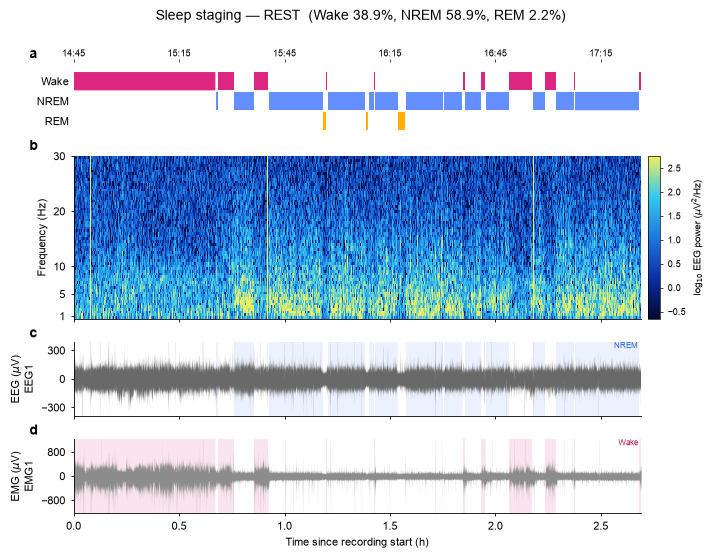

Saved fig_staging_REST.png / .pdf


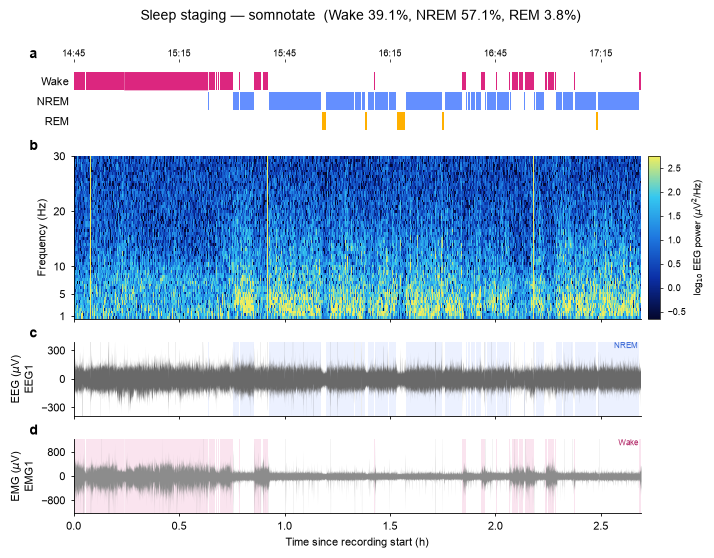

Saved fig_staging_somnotate.png / .pdf


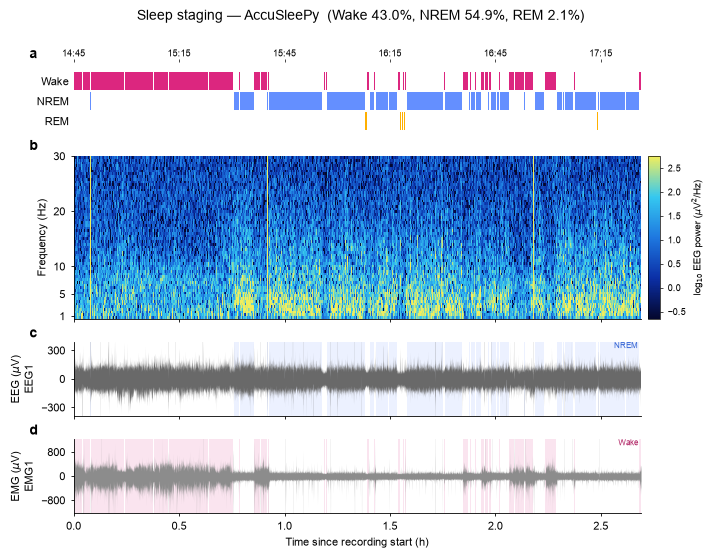

Saved fig_staging_AccuSleePy.png / .pdf


In [11]:
# ---- 7.1 one figure per method ---------------------------------------------
for tool in TOOLS:
    vec = vecs[tool]
    fig = plt.figure(figsize=(7.09, 5.6))
    gs = fig.add_gridspec(4, 1, height_ratios=[1.0, 2.3, 1.05, 1.05],
                          hspace=0.24, left=0.095, right=0.895, top=0.895, bottom=0.09)

    # a: hypnogram (state raster)
    axH = fig.add_subplot(gs[0])
    for s, ypos in [(3, 0), (2, 1), (1, 2)]:
        axH.fill_between(hours, ypos, ypos + 0.92, where=(vec == s),
                         step="mid", color=STATE_COLORS[s], lw=0)
    axH.set_yticks([0.46, 1.46, 2.46])
    axH.set_yticklabels(["REM", "NREM", "Wake"])
    axH.set_ylim(-0.15, 3.4)
    axH.set_xlim(0, dur_h)
    axH.set_xticklabels([])
    for sp in ["left", "bottom"]:
        axH.spines[sp].set_visible(False)
    axH.tick_params(length=0)

    # b: EEG spectrogram
    axS = fig.add_subplot(gs[1])
    im = axS.imshow(S, aspect="auto", origin="lower", cmap=SPEC_CMAP,
                    extent=[0, dur_h, freqs[fmask][0], freqs[fmask][-1]],
                    vmin=vmin, vmax=vmax, interpolation="nearest")
    axS.set_ylabel("Frequency (Hz)")
    axS.set_yticks([1, 5, 10, 20, 30])
    axS.set_xlim(0, dur_h)
    axS.set_xticklabels([])
    cax = axS.inset_axes([1.012, 0.0, 0.022, 1.0])
    cb = fig.colorbar(im, cax=cax)
    cb.set_label(r"log$_{10}$ EEG power ($\mu$V$^2$/Hz)", fontsize=7)
    cb.outline.set_linewidth(0.5)
    cb.ax.tick_params(labelsize=6.5, width=0.5, length=2)

    # c: raw EEG envelope (1 s min/max), NREM shading
    axD = fig.add_subplot(gs[2])
    axD.fill_between(hours, -eeg_ylim, eeg_ylim, where=(vec == 2), step="mid",
                     color="#648FFF", alpha=0.12, lw=0)
    axD.fill_between(t_env, eeg_lo, eeg_hi, color=WAVE_GRAY_EEG, lw=0)
    axD.set_ylim(-eeg_ylim, eeg_ylim)
    axD.set_xlim(0, dur_h)
    axD.set_ylabel(f"EEG ($\\mu$V)\n{EEG_CH}")
    eeg_yt = int(round(eeg_ylim * 2 / 3 / 100) * 100)
    axD.set_yticks([-eeg_yt, 0, eeg_yt])
    axD.set_xticklabels([])
    axD.text(dur_h * 0.995, eeg_ylim * 0.83, "NREM", ha="right", fontsize=6, color="#3D6BD6")

    # d: raw EMG envelope, Wake shading
    axE = fig.add_subplot(gs[3])
    axE.fill_between(hours, -emg_ylim, emg_ylim, where=(vec == 1), step="mid",
                     color="#DC267F", alpha=0.12, lw=0)
    axE.fill_between(t_env, emg_lo, emg_hi, color=WAVE_GRAY_EMG, lw=0)
    axE.set_ylim(-emg_ylim, emg_ylim)
    axE.set_xlim(0, dur_h)
    axE.set_ylabel(f"EMG ($\\mu$V)\n{EMG_CH}")
    axE.set_xlabel("Time since recording start (h)")
    emg_yt = int(round(emg_ylim * 2 / 3 / 100) * 100)
    axE.set_yticks([-emg_yt, 0, emg_yt])
    axE.text(dur_h * 0.995, emg_ylim * 0.83, "Wake", ha="right", fontsize=6, color="#B02163")

    # secondary axis on top: wall-clock when START is known, else elapsed hours
    sec = axH.secondary_xaxis("top", functions=(lambda h: h, lambda h: h))
    tk = np.arange(0, dur_h, 0.5)
    sec.set_xticks(tk)
    if start_dt is not None:
        sec.set_xticklabels([(start_dt + timedelta(hours=float(t))).strftime("%H:%M") for t in tk],
                            fontsize=6.5)
    else:
        sec.set_xticklabels([f"{t:.1f}" for t in tk], fontsize=6.5)
    sec.tick_params(length=2, width=0.5, pad=1)
    sec.spines["top"].set_visible(False)

    for ax, letter in [(axH, "a"), (axS, "b"), (axD, "c"), (axE, "d")]:
        ax.text(-0.078, 1.02, letter, transform=ax.transAxes,
                fontsize=10, fontweight="bold", va="bottom", ha="left")

    tot = max((vec > 0).sum(), 1)
    txt = ", ".join(f"{STATE_NAMES[s]} {100 * (vec == s).sum() / tot:.1f}%"
                    for s in (1, 2, 3) if (vec == s).any())
    fig.suptitle(f"Sleep staging — {tool}  ({txt})", fontsize=10, y=0.99)
    fig.savefig(RUN_DIR / f"fig_staging_{tool}.png", dpi=350)
    fig.savefig(RUN_DIR / f"fig_staging_{tool}.pdf")
    plt.show()
    print(f"Saved fig_staging_{tool}.png / .pdf")

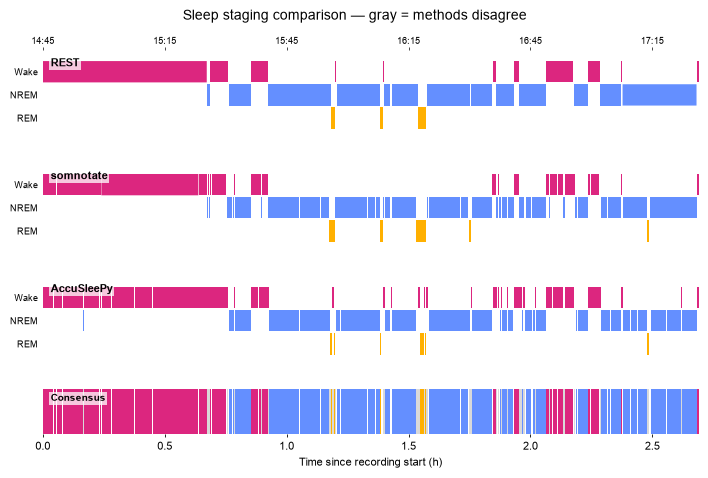

Saved fig_methods_comparison.png / .pdf


In [12]:
# ---- 7.2 comparison across methods -----------------------------------------
fig = plt.figure(figsize=(7.09, 4.8))
gs = fig.add_gridspec(4, 1, height_ratios=[1, 1, 1, 0.55],
                      hspace=0.42, left=0.06, right=0.985, top=0.9, bottom=0.1)

for i, tool in enumerate(TOOLS):
    ax = fig.add_subplot(gs[i])
    vec = vecs[tool]
    for s, ypos in [(3, 0), (2, 1), (1, 2)]:
        ax.fill_between(hours, ypos, ypos + 0.92, where=(vec == s),
                        step="mid", color=STATE_COLORS[s], lw=0)
    ax.set_yticks([0.46, 1.46, 2.46])
    ax.set_yticklabels(["REM", "NREM", "Wake"], fontsize=6.5)
    ax.set_ylim(-0.15, 3.4)
    ax.set_xlim(0, dur_h)
    ax.text(0.012, 0.9, tool, transform=ax.transAxes, fontsize=8,
            fontweight="bold", va="top", ha="left",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.2))
    ax.set_xticklabels([])
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_visible(False)
    ax.tick_params(length=0)
    if i == 0:
        sec = ax.secondary_xaxis("top", functions=(lambda h: h, lambda h: h))
        tk = np.arange(0, dur_h, 0.5)
        sec.set_xticks(tk)
        if start_dt is not None:            # wall-clock labels when START is known
            sec.set_xticklabels([(start_dt + timedelta(hours=float(t))).strftime("%H:%M") for t in tk],
                                fontsize=6.5)
        else:                               # otherwise elapsed hours
            sec.set_xticklabels([f"{t:.1f}" for t in tk], fontsize=6.5)
        sec.tick_params(length=2, width=0.5, pad=1)
        sec.spines["top"].set_visible(False)

# bottom row: unanimous consensus (colored by state) vs disagreement (gray)
axA = fig.add_subplot(gs[3])
same = ((vecs["REST"] == vecs["somnotate"]) & (vecs["somnotate"] == vecs["AccuSleePy"]))
for s in (1, 2, 3):
    axA.fill_between(hours, 0, 1, where=(vecs["REST"] == s) & same, step="mid",
                     color=STATE_COLORS[s], lw=0)
axA.fill_between(hours, 0, 1, where=~same, step="mid", color="#D9D9D9", lw=0)
axA.set_ylim(0, 1)
axA.set_xlim(0, dur_h)
axA.set_yticks([])
axA.text(0.012, 0.9, "Consensus", transform=axA.transAxes, fontsize=7.5,
         fontweight="bold", va="top", ha="left",
         bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.2))
axA.set_xlabel("Time since recording start (h)")
for sp in ["left", "bottom"]:
    axA.spines[sp].set_visible(False)
axA.tick_params(length=2, width=0.6)

fig.suptitle("Sleep staging comparison — gray = methods disagree", fontsize=10, y=0.985)
fig.savefig(RUN_DIR / "fig_methods_comparison.png", dpi=350)
fig.savefig(RUN_DIR / "fig_methods_comparison.pdf")
plt.show()
print("Saved fig_methods_comparison.png / .pdf")

## Output files

**Each run creates `results/<recording><TAG>_<timestamp>/` containing:**

| File | Content |
|------|---------|
| `<recording><TAG>_REST_V2.0.mat` | REST staging (1=Wake 2=NREM 3=REM 4=artifact) |
| `<recording><TAG>_automated.hyp` | somnotate staging (state intervals) |
| `<recording><TAG>_accusleepy_labels.csv` | AccuSleePy staging (1=REM 2=Wake 3=NREM) |
| `sleep_stats_summary.csv` | Wake/NREM/REM fractions per method + agreement |
| `fig_staging_<method>.png/.pdf` | one figure per method (raster + spectrogram + waveforms) |
| `fig_methods_comparison.png/.pdf` | comparison across the three methods |

**Intermediates** (managed automatically): `edf/cache/` (1 kHz decimation
cache), `edf/rest/` (EDF), `somnotate_run/data/` (preprocessing & training
data), `accusleepy_run/` (parquet/calibration/pseudo-labels, `ssann_4s.pth`
model).

## References

- REST: Shi et al., *A refined, comprehensive protocol for automated sleep staging in mice* — https://github.com/SukiyakiP/REST
- somnotate: Brodersen et al. — https://github.com/paulbrodersen/somnotate (training data Zenodo doi:10.5281/zenodo.10200482)
- AccuSleePy: Barger et al. (2019) *PLOS ONE* — https://github.com/zekebarger/AccuSleePy (models https://osf.io/py5eb/)

## FAQ

- **Don't know the exact recording start time?** Set `START = None`. Nothing
  in the staging depends on it; the top axis of the figures then shows elapsed
  time (h) instead of wall-clock, and the EDF header gets a placeholder date.
- **Results unchanged after editing TIME_CLIP or the recording?** Every run
  creates a fresh folder and re-runs everything. The 1 kHz decimation cache is
  keyed on source file + size and is recomputed automatically when the source
  changes (or force it with `RERUN = ["dat"]`).
- **somnotate complains about pomegranate?** Make sure `SOMNOTATE_PY` points
  to an environment with Python ≤ 3.9 and `pomegranate<1.0` installed.
- **REST reports a missing checkpoint?** Check that
  `tools/REST/checkpoints/Deeper_and_wider/best_acc.pth` exists.
- **AccuSleePy reports a missing model?** Download `ssann_4s.pth` from
  https://osf.io/py5eb/ and place it in `accusleepy_run/`.